# 01 — Play-by-Play EDA

Exploratory analysis of `data/interim/pbp_clean.parquet`.

Sections:
1. Yards Gained
2. Quantitative Features
3. Quantitative Relationships (Correlation Heatmap)
4. Categorical Relationships
5. Run vs. Pass Plays
6. Play Type by Down
7. Environment Effects (Roof / Surface)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

ROOT = Path("..").resolve()
pbp = pd.read_parquet(ROOT / "data/interim/pbp_clean.parquet")

print(f"Shape:   {pbp.shape}")
print(f"Seasons: {sorted(pbp['season'].unique())}")
pbp.head()

Shape:   (279917, 32)
Seasons: [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


,game_id,play_id,season,week,game_date,season_type,home_team,away_team,posteam,defteam,posteam_type,game_half,qtr,quarter_seconds_remaining,half_seconds_remaining,game_seconds_remaining,down,ydstogo,yardline_100,posteam_score,defteam_score,play_type,offense_formation,defenders_in_box,number_of_pass_rushers,offense_personnel,defense_personnel,roof,surface,temp,wind,yards_gained
0,2024_01_ARI_BUF,61.000,2024,1,2024-09-08,REG,BUF,ARI,ARI,BUF,away,Half1,1,900.000,1800.000,3600.000,1,10,70.000,0,0,run,UNDER CENTER,7,0,"2 C, 1 G, 1 QB, 1 RB, 2 T, 1 TE, 3 WR","3 CB, 2 DE, 2 DT, 1 MLB, 1 OLB, 2 SS",outdoors,a_turf,61.000,20.000,3.000
1,2024_01_ARI_BUF,83.000,2024,1,2024-09-08,REG,BUF,ARI,ARI,BUF,away,Half1,1,867.000,1767.000,3567.000,2,7,67.000,0,0,pass,UNDER CENTER,6,4,"2 C, 1 G, 1 QB, 1 RB, 2 T, 2 TE, 2 WR","3 CB, 2 DE, 2 DT, 1 MLB, 1 OLB, 2 SS",outdoors,a_turf,61.000,20.000,22.000
2,2024_01_ARI_BUF,108.000,2024,1,2024-09-08,REG,BUF,ARI,ARI,BUF,away,Half1,1,823.000,1723.000,3523.000,1,10,45.000,0,0,pass,SHOTGUN,6,4,"2 C, 1 G, 1 QB, 1 RB, 2 T, 2 TE, 2 WR","3 CB, 2 DE, 2 DT, 1 MLB, 1 OLB, 2 SS",outdoors,a_turf,61.000,20.000,9.000
3,2024_01_ARI_BUF,133.000,2024,1,2024-09-08,REG,BUF,ARI,ARI,BUF,away,Half1,1,782.000,1682.000,3482.000,2,1,36.000,0,0,run,UNDER CENTER,8,0,"2 C, 1 G, 1 QB, 1 RB, 2 T, 3 TE, 1 WR","3 CB, 2 DE, 2 DT, 1 MLB, 1 OLB, 2 SS",outdoors,a_turf,61.000,20.000,2.000
4,2024_01_ARI_BUF,155.000,2024,1,2024-09-08,REG,BUF,ARI,ARI,BUF,away,Half1,1,746.000,1646.000,3446.000,1,10,34.000,0,0,run,PISTOL,7,0,"2 C, 1 G, 1 QB, 1 RB, 2 T, 3 TE, 1 WR","3 CB, 2 DE, 2 DT, 1 MLB, 1 OLB, 2 SS",outdoors,a_turf,61.000,20.000,2.000


In [126]:
# Column names, length, null values & data types
pbp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279917 entries, 0 to 279916
Data columns (total 32 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   game_id                    279917 non-null  object 
 1   play_id                    279917 non-null  float32
 2   season                     279917 non-null  int64  
 3   week                       279917 non-null  Int64  
 4   game_date                  279917 non-null  object 
 5   season_type                279917 non-null  object 
 6   home_team                  279917 non-null  object 
 7   away_team                  279917 non-null  object 
 8   posteam                    279917 non-null  object 
 9   defteam                    279917 non-null  object 
 10  posteam_type               279917 non-null  object 
 11  game_half                  279917 non-null  object 
 12  qtr                        279917 non-null  Int64  
 13  quarter_seconds_remaining  27

In [ ]:
# Printing out all columns in data
print(pbp.columns.tolist())

['game_id', 'play_id', 'season', 'week', 'game_date', 'season_type', 'home_team', 'away_team', 'posteam', 'defteam', 'posteam_type', 'game_half', 'qtr', 'quarter_seconds_remaining', 'half_seconds_remaining', 'game_seconds_remaining', 'down', 'ydstogo', 'yardline_100', 'posteam_score', 'defteam_score', 'play_type', 'offense_formation', 'defenders_in_box', 'number_of_pass_rushers', 'offense_personnel', 'defense_personnel', 'roof', 'surface', 'temp', 'wind', 'yards_gained']


## Exploring Yards Gained

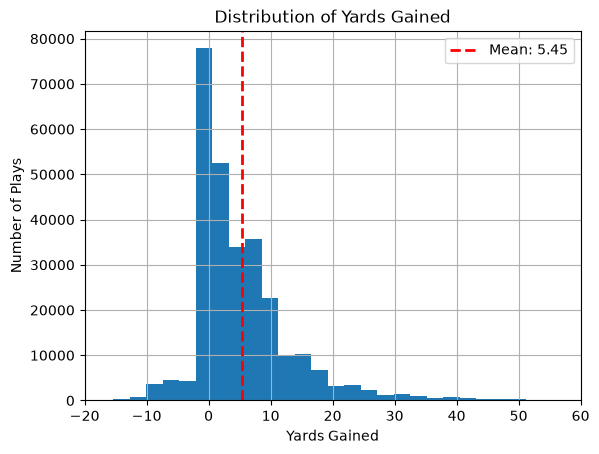

In [128]:
# Visualizing distribution of yards gained per play
pbp["yards_gained"].hist(bins=50)

# Highlighting excpected yards per play
exp_yards = pbp["yards_gained"].mean()
plt.axvline(exp_yards, color="red", linestyle="dashed", 
            linewidth=2, label=f"Mean: {exp_yards:.2f}")

plt.xlabel("Yards Gained")
plt.ylabel("Number of Plays")
plt.title("Distribution of Yards Gained")
plt.xlim(-20, 60)
plt.legend()
plt.show()

In [129]:
# Basic summary statistics
pbp["yards_gained"].describe()

count    279917.000000
mean          5.448522
std           8.616379
min         -34.000000
25%           0.000000
50%           3.000000
75%           8.000000
max          99.000000
Name: yards_gained, dtype: float64

## Quantitative Features

In [1]:
# Quantitative (numeric) features
num_cols = [
    "quarter_seconds_remaining",
    "half_seconds_remaining",
    "game_seconds_remaining",
    "ydstogo",
    "yardline_100",
    "posteam_score",
    "defteam_score",
    "defenders_in_box",
    "number_of_pass_rushers",
    "temp",
    "wind",
]

# Categorical features
cat_cols = [
    "season",
    "week",
    "season_type",
    "posteam_type",
    "qtr",
    "down",
    "play_type",
    "offense_formation",
    "offense_personnel",
    "defense_personnel",
    "posteam",
    "defteam",
    "roof",
    "surface",
]

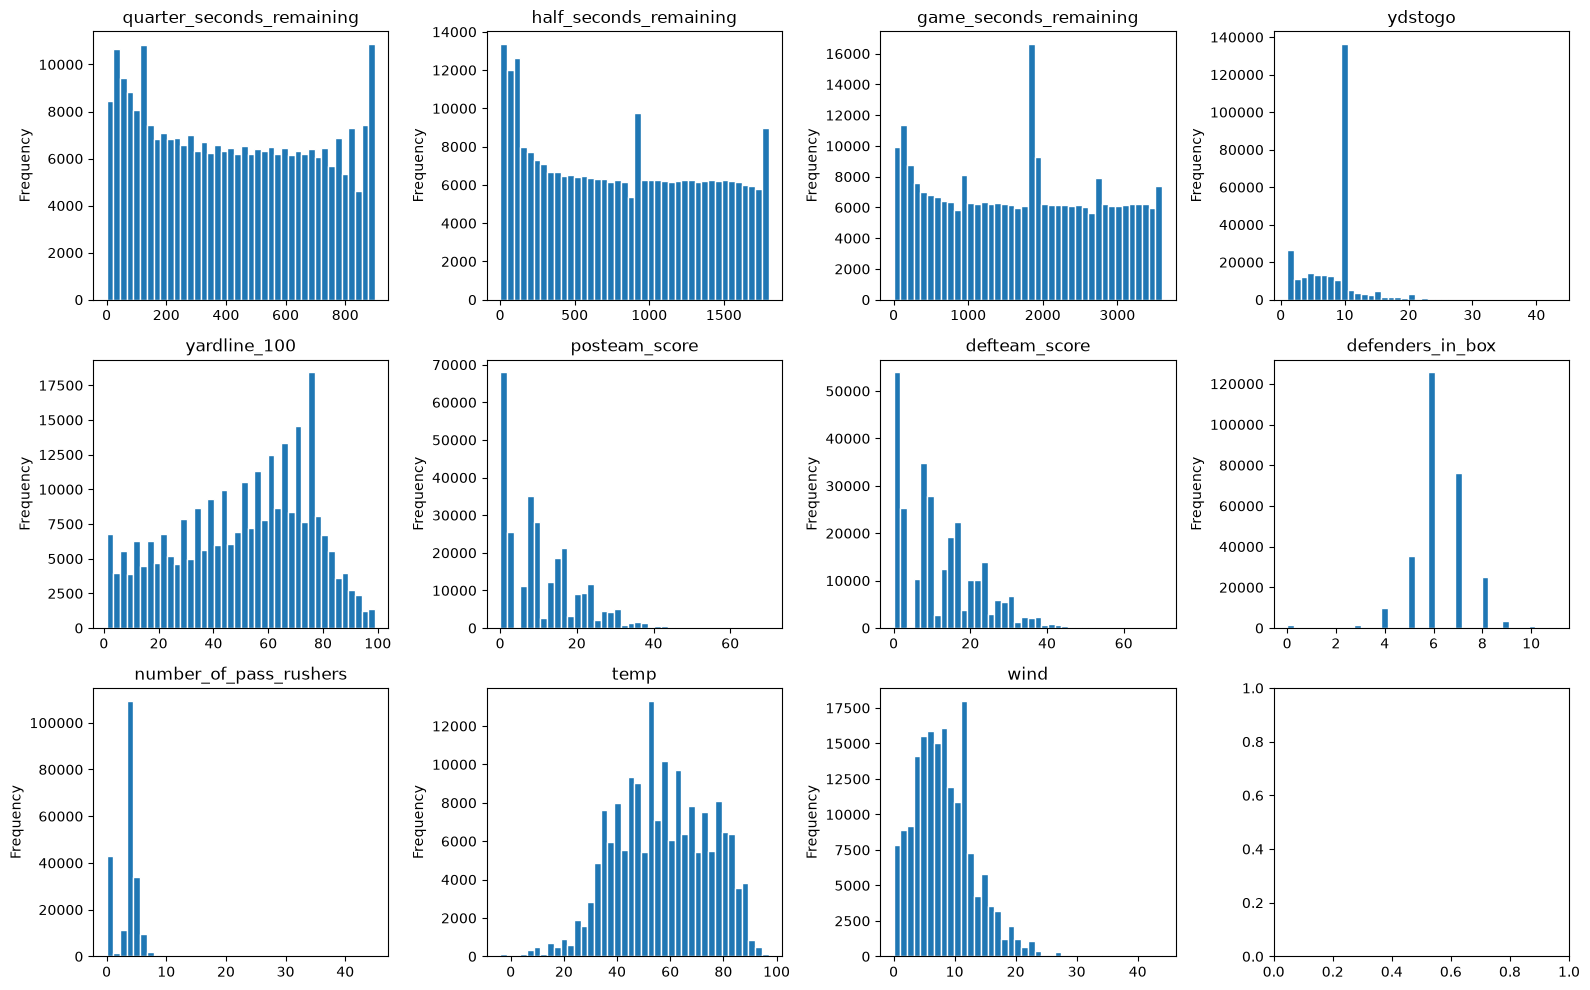

In [149]:
# Examining distributions of each quantitative feature
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    pbp[col].dropna().plot.hist(ax=axes[i], bins=40, edgecolor="white")
    axes[i].set_title(col)
    axes[i].set_xlabel("")

for ax in axes[len(num_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

By examining the distributions of each feature, we can examine a couple of behaviors:
1) There is a spike in plays right before halftime, this shows how offenses attempt to maximize the amount of plays they run during the two-minute drill before halftime.
2) Most plays are 10 yards away from the down marker. This reflects each first down along with failed conversions on other downs.
3) There is an interesting increasing pattern with systematic spikes for where on the field plays are beginning.
4) The most common score for a game is 0.
5) The most common amount of pass rushers on a given play is three.

## Quantitative Relationships w/ Yards Gained

### Correlation Heatmap

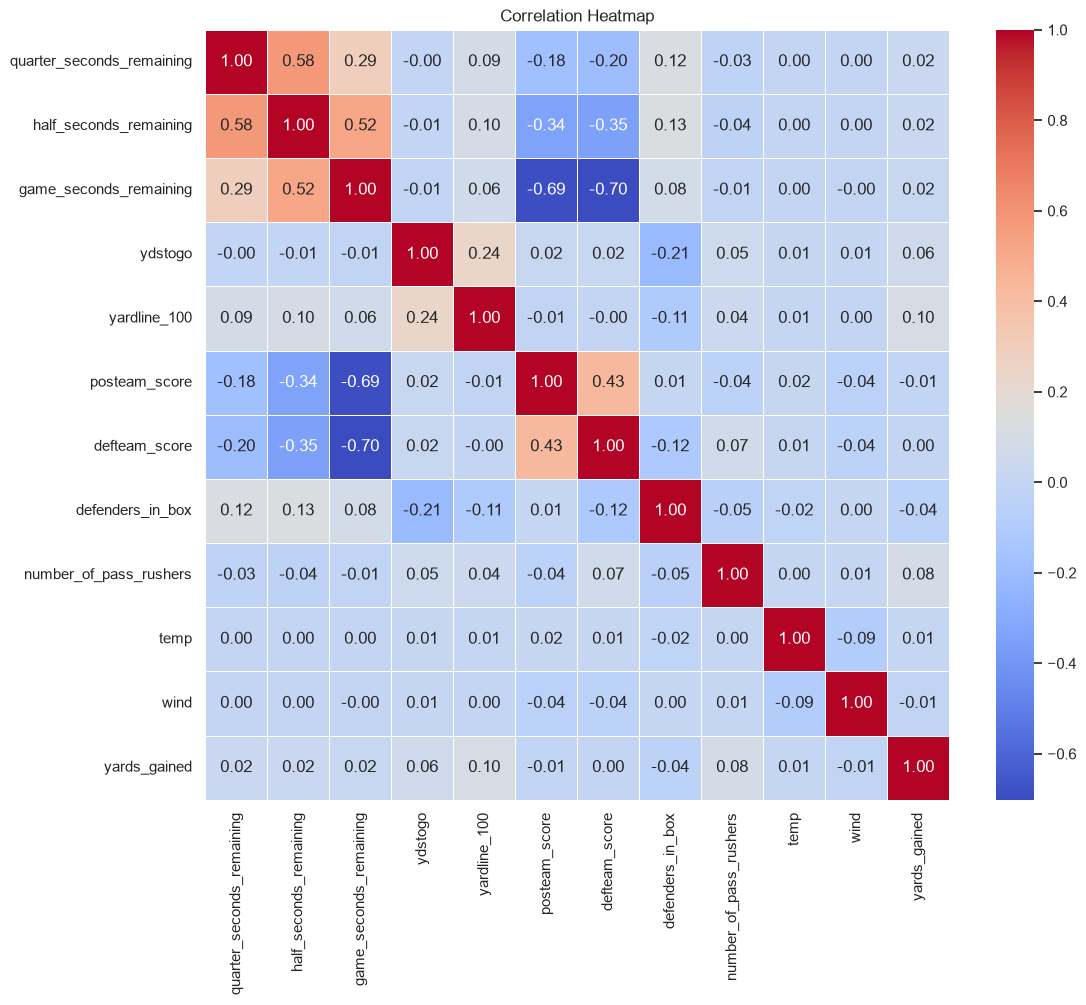

In [5]:
# Compute correlations using only quantitative variables
corr = pbp[num_cols + ["yards_gained"]].corr()

# Plotting correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,    
    cmap="coolwarm", 
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

This correlation heatmap indicates that there are no features with even moderate correlation with yards gained. This method uses Pearson correlation which captures linear relationships, hinting that a linear model may be a weak predictor.


Even still, there are some observations we can make from this:
1) Yard line has the highest correlation with yards gained. This intuitively makes sense as if a play is starting in the red zone they have less field to work with, or if they are backed up they might settle for a short gain to make space.
2) Some qualitative features are correlated with each other. Interestingly, team scores have strong to moderate correlation with the time remaining. Another interesting relationship is the weak to moderate correlation between the number of defenders in the box and the number of yards until a first down which makes more sense as the defense might want to put more defenders in the box when the offense is near a first down.

## Categorical Relationships w/ Target Variable

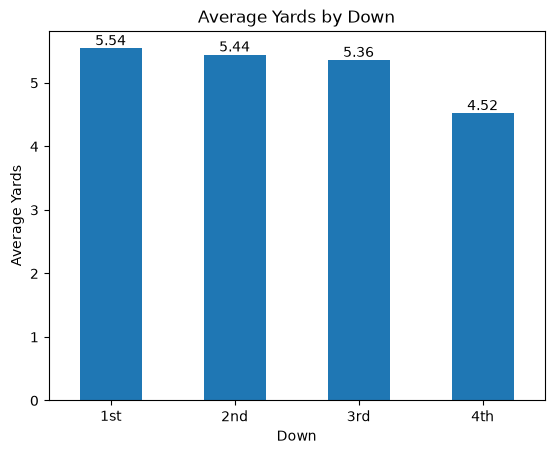

In [132]:
# Plotting average yards by down
ax = pbp.groupby("down")["yards_gained"].mean().plot.bar()

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

plt.xticks(ticks=range(4), labels=["1st", "2nd", "3rd", "4th"], rotation=0)
plt.xlabel("Down")
plt.ylabel("Average Yards")
plt.title("Average Yards by Down")
plt.show()

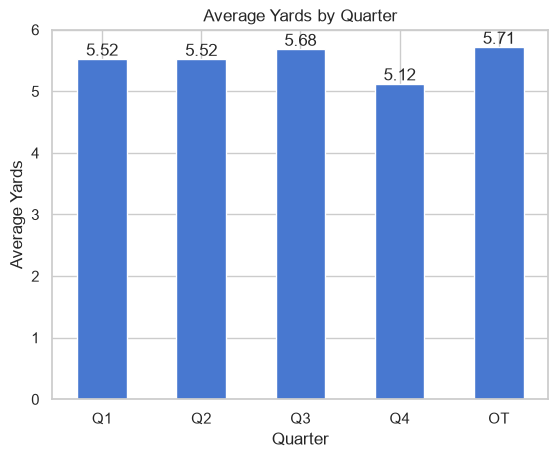

In [7]:
# Plotting average yards by quarter
ax = pbp.groupby("qtr")["yards_gained"].mean().plot.bar()

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

plt.xticks(ticks=range(5), labels=["Q1", "Q2", "Q3", "Q4", "OT"], rotation=0)
plt.xlabel("Quarter")
plt.ylabel("Average Yards")
plt.title("Average Yards by Quarter")
plt.show()

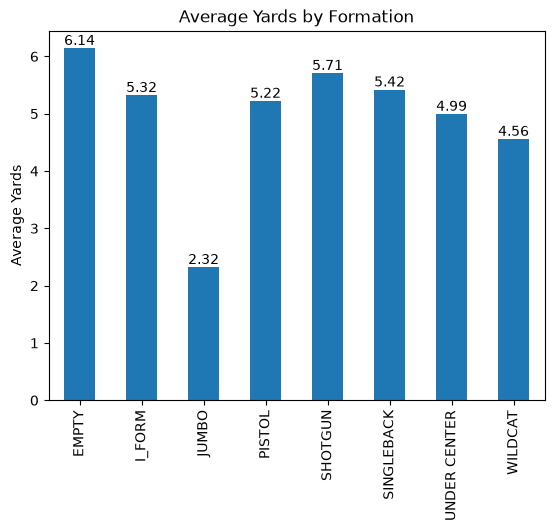

In [ ]:
# Plotting average yards by formation
ax = pbp.groupby("offense_formation")["yards_gained"].mean().plot.bar()

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

plt.xlabel("")
plt.ylabel("Average Yards")
plt.title("Average Yards by Formation")
plt.show()

## Examining Run vs. Pass Plays

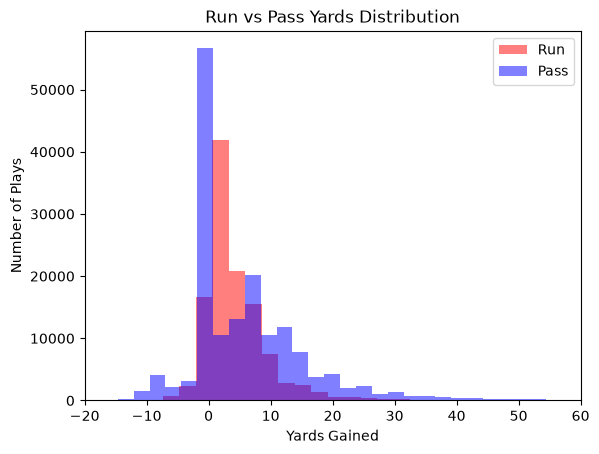

In [146]:
# Filtering run/pass plays
run_plays = pbp[pbp["play_type"] == "run"]["yards_gained"]
pass_plays = pbp[pbp["play_type"] == "pass"]["yards_gained"]

# Plotting overlayed distributions
plt.hist(run_plays, bins=50, alpha=0.5, color="red", label="Run")
plt.hist(pass_plays, bins=50, alpha=0.5, color="blue", label="Pass")

plt.xlabel("Yards Gained")
plt.ylabel("Number of Plays")
plt.title("Run vs Pass Yards Distribution")
plt.xlim(-20, 60)

plt.legend()
plt.show()

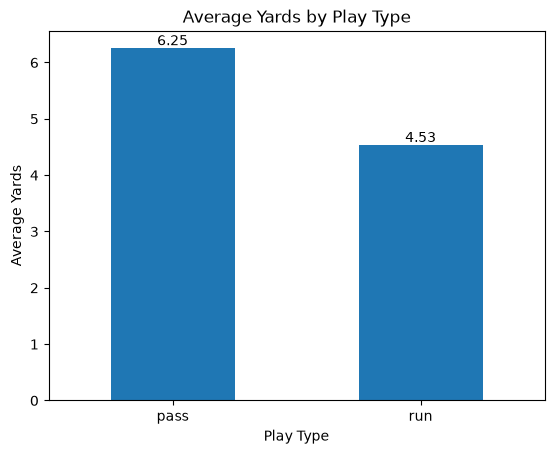

In [145]:
ax = pbp[pbp["play_type"] != "qb_kneel"].groupby("play_type")["yards_gained"].mean().plot.bar()

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

plt.xticks(rotation=0)
plt.xlabel("Play Type")
plt.ylabel("Average Yards")
plt.title("Average Yards by Play Type")
plt.show()

As we can see, run plays and pass plays have different expected yards per play as well distributions. While we do not know if a play is run or pass before the snap, it might be helpful to engineer a feature which models the probability of a pass play.

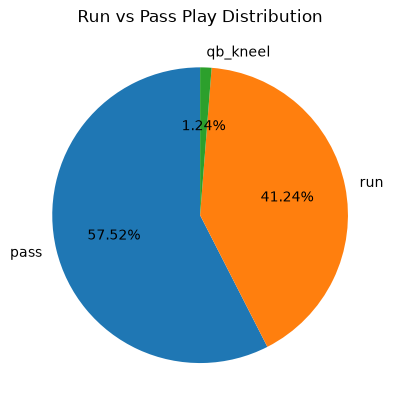

In [56]:
play_type_counts = pbp["play_type"].value_counts()

play_type_counts.plot.pie(
    autopct="%1.2f%%",
    startangle=90
)
plt.title("Run vs Pass Play Distribution")
plt.ylabel("")
plt.show()

Proportion of play types per season:
────────────────────────────────────────
  2018:  Run 40.0%   Pass 58.8%
  2019:  Run 40.2%   Pass 58.6%
  2020:  Run 40.6%   Pass 58.1%
  2021:  Run 40.8%   Pass 58.0%
  2022:  Run 42.0%   Pass 56.8%
  2023:  Run 41.3%   Pass 57.5%
  2024:  Run 42.5%   Pass 56.3%
  2025:  Run 42.5%   Pass 56.2%


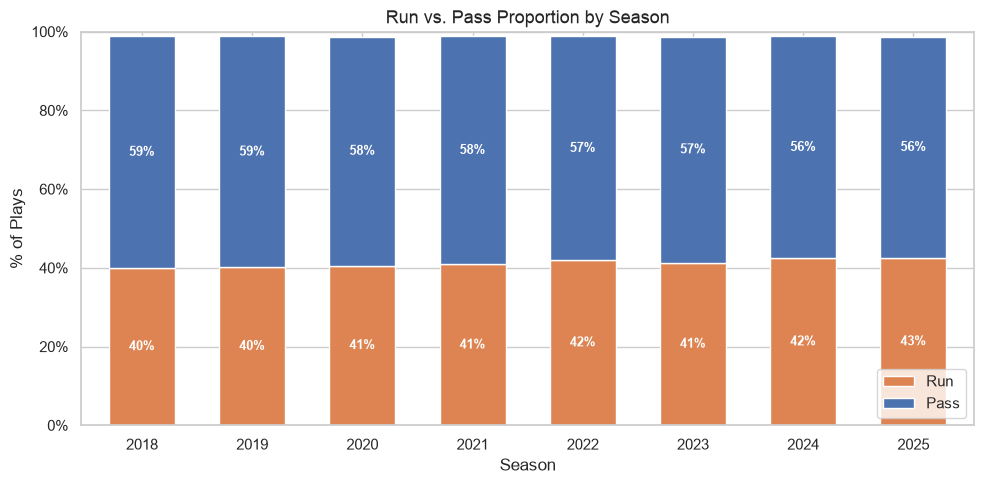

In [13]:
# Run/Pass proportion by season
season_play_counts = pbp.groupby(["season", "play_type"]).size().unstack(fill_value=0)
season_play_props = season_play_counts.div(season_play_counts.sum(axis=1), axis=0)

# Print summary
print("Proportion of play types per season:")
print("─" * 40)
for season in season_play_props.index:
    run_pct  = season_play_props.loc[season].get("run",  0) * 100
    pass_pct = season_play_props.loc[season].get("pass", 0) * 100
    print(f"  {season}:  Run {run_pct:.1f}%   Pass {pass_pct:.1f}%")

# Stacked bar chart
fig, ax = plt.subplots(figsize=(10, 5))
rp = season_play_props[["run", "pass"]] * 100
rp.plot.bar(ax=ax, stacked=True, color=["#DD8452", "#4C72B0"], edgecolor="white", width=0.6)

ax.set_title("Run vs. Pass Proportion by Season", fontsize=13)
ax.set_xlabel("Season")
ax.set_ylabel("% of Plays")
ax.set_xticklabels(rp.index, rotation=0)
ax.legend(["Run", "Pass"], loc="lower right")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim(0, 100)

n_groups = len(rp)
for bar in ax.patches:
    h = bar.get_height()
    if h > 4:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_y() + h / 2,
            f"{h:.0f}%", ha="center", va="center",
            color="white", fontsize=9, fontweight="bold",
        )

plt.tight_layout()
plt.show()

Offensive tendencies typically vary by era. Mainly, NFL offenses today prioritize the passing game, whereas the running game was the focal point of offenses in the past. However, in the seven seasons of data we have (2018–2024), run/pass proportions remain relatively stable with slight increases in run plays in recent years.

## 6. Play Type by Down

How do run/pass tendencies and average yards shift across downs? A heatmap of average yards gained (run vs. pass × down) reveals how the offense and defense adapt.

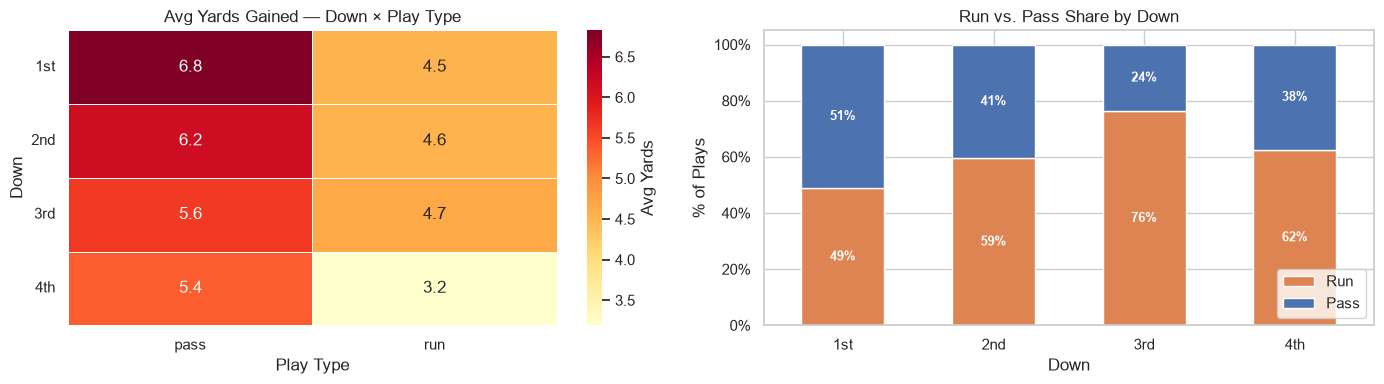

In [14]:
rp = pbp[pbp["play_type"].isin(["run", "pass"])].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Avg yards heatmap (down × play_type) ─────────────────────────────────────
pivot_yards = (
    rp.groupby(["down", "play_type"])["yards_gained"]
    .mean()
    .unstack("play_type")
)
sns.heatmap(
    pivot_yards, ax=axes[0], annot=True, fmt=".1f",
    cmap="YlOrRd", linewidths=0.5, cbar_kws={"label": "Avg Yards"},
)
axes[0].set_title("Avg Yards Gained — Down × Play Type", fontsize=12)
axes[0].set_xlabel("Play Type")
axes[0].set_ylabel("Down")
axes[0].set_yticklabels(["1st", "2nd", "3rd", "4th"], rotation=0)

# ── Run/pass share by down (stacked bar) ─────────────────────────────────────
pivot_share = (
    rp.groupby(["down", "play_type"])
    .size()
    .unstack("play_type", fill_value=0)
    .apply(lambda r: r / r.sum() * 100, axis=1)
)
pivot_share.plot.bar(
    ax=axes[1], stacked=True,
    color=["#DD8452", "#4C72B0"], edgecolor="white", width=0.55,
)
axes[1].set_title("Run vs. Pass Share by Down", fontsize=12)
axes[1].set_xlabel("Down")
axes[1].set_ylabel("% of Plays")
axes[1].set_xticklabels(["1st", "2nd", "3rd", "4th"], rotation=0)
axes[1].legend(["Run", "Pass"], loc="lower right")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())

for bar in axes[1].patches:
    h = bar.get_height()
    if h > 4:
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_y() + h / 2,
            f"{h:.0f}%", ha="center", va="center",
            color="white", fontsize=9, fontweight="bold",
        )

plt.tight_layout()
plt.show()

## 7. Environment Effects

Does playing in a dome or on turf actually produce more yards? These are pre-snap observable features, so they're fair game as model inputs.

In [ ]:
rp = pbp[pbp["play_type"].isin(["run", "pass"])].copy()
rp["surface_clean"] = rp["surface"].str.lower().str.strip()

# Keep top 6 surfaces by play count to avoid clutter
top_surfaces = rp["surface_clean"].value_counts().head(6).index
rp_surf = rp[rp["surface_clean"].isin(top_surfaces)].copy()

def share_and_yards(df, col):
    counts = df.groupby([col, "play_type"]).size().unstack("play_type", fill_value=0)
    share  = counts.div(counts.sum(axis=1), axis=0) * 100
    yards  = df.groupby([col, "play_type"])["yards_gained"].mean().unstack("play_type")
    return share, yards

roof_share,    roof_yards    = share_and_yards(rp,      "roof")
surface_share, surface_yards = share_and_yards(rp_surf, "surface_clean")

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ── Row 0: run/pass share ───────────────────────────────────────────────
for ax, share, title, xlabel, rot in [
    (axes[0, 0], roof_share,    "Run / Pass Share by Roof Type", "Roof Type",  0),
    (axes[0, 1], surface_share, "Run / Pass Share by Surface",   "Surface",   30),
]:
    share[["run", "pass"]].plot.bar(
        ax=ax, stacked=True,
        color=["#DD8452", "#4C72B0"], edgecolor="white", width=0.6,
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("% of Plays")
    ax.set_xticklabels(share.index, rotation=rot)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_ylim(0, 100)
    ax.legend(["Run", "Pass"], loc="lower right")
    for bar in ax.patches:
        h = bar.get_height()
        if h > 4:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + h / 2,
                f"{h:.0f}%", ha="center", va="center",
                color="white", fontsize=8.5, fontweight="bold",
            )

# ── Row 1: average yards ──────────────────────────────────────────────────
width = 0.38
for ax, yards, title, xlabel, rot in [
    (axes[1, 0], roof_yards,    "Avg Yards Gained by Roof Type", "Roof Type",  0),
    (axes[1, 1], surface_yards, "Avg Yards Gained by Surface",   "Surface",   30),
]:
    x = np.arange(len(yards))
    b_run  = ax.bar(x - width / 2, yards["run"],  width, label="Run",  color="#DD8452", edgecolor="white")
    b_pass = ax.bar(x + width / 2, yards["pass"], width, label="Pass", color="#4C72B0", edgecolor="white")
    for bar in [*b_run, *b_pass]:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, h + 0.1,
            f"{h:.1f}", ha="center", va="bottom", fontsize=8.5,
        )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Avg Yards")
    ax.set_xticks(x)
    ax.set_xticklabels(yards.index, rotation=rot)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


Outdoor run/pass plays: 172,579


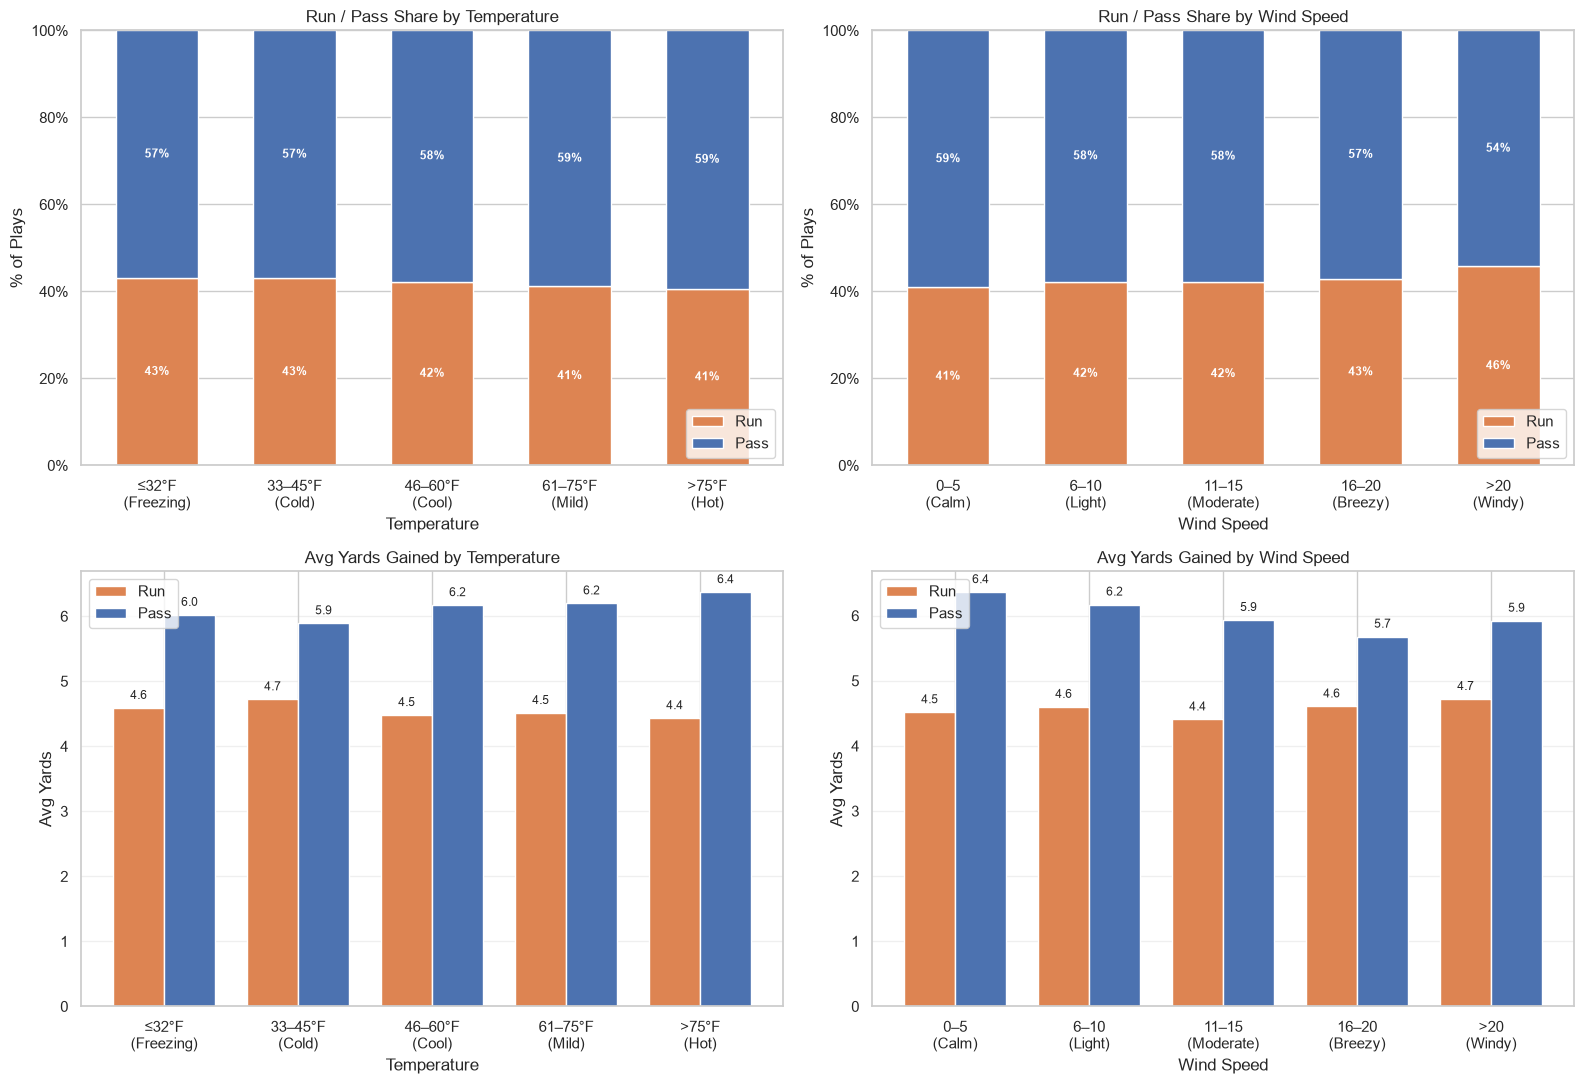

In [15]:
outdoor = pbp[
    pbp["play_type"].isin(["run", "pass"]) &
    pbp["roof"].isin(["outdoors", "open"]) &
    pbp["temp"].notna() &
    pbp["wind"].notna()
].copy()

print(f"Outdoor run/pass plays: {len(outdoor):,}")

# ── Bucket temperature and wind ──────────────────────────────────────────────
outdoor["temp_bucket"] = pd.cut(
    outdoor["temp"],
    bins=[-5, 32, 45, 60, 75, 100],
    labels=["≤32°F\n(Freezing)", "33–45°F\n(Cold)", "46–60°F\n(Cool)", "61–75°F\n(Mild)", ">75°F\n(Hot)"],
)
outdoor["wind_bucket"] = pd.cut(
    outdoor["wind"],
    bins=[-1, 5, 10, 15, 20, 50],
    labels=["0–5\n(Calm)", "6–10\n(Light)", "11–15\n(Moderate)", "16–20\n(Breezy)", ">20\n(Windy)"],
)

def run_pass_share(df, bucket_col):
    counts = df.groupby([bucket_col, "play_type"]).size().unstack("play_type", fill_value=0)
    return counts.div(counts.sum(axis=1), axis=0) * 100

def avg_yards_by_bucket(df, bucket_col):
    return (
        df.groupby([bucket_col, "play_type"])["yards_gained"]
        .mean()
        .unstack("play_type")
    )

temp_share = run_pass_share(outdoor, "temp_bucket")
wind_share = run_pass_share(outdoor, "wind_bucket")
temp_yards = avg_yards_by_bucket(outdoor, "temp_bucket")
wind_yards = avg_yards_by_bucket(outdoor, "wind_bucket")

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ── Row 0: run/pass share ─────────────────────────────────────────────────────
for ax, share, title, xlabel in [
    (axes[0, 0], temp_share, "Run / Pass Share by Temperature", "Temperature"),
    (axes[0, 1], wind_share, "Run / Pass Share by Wind Speed",  "Wind Speed"),
]:
    share[["run", "pass"]].plot.bar(
        ax=ax, stacked=True,
        color=["#DD8452", "#4C72B0"], edgecolor="white", width=0.6,
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("% of Plays")
    ax.set_xticklabels(share.index, rotation=0)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_ylim(0, 100)
    ax.legend(["Run", "Pass"], loc="lower right")
    for bar in ax.patches:
        h = bar.get_height()
        if h > 4:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + h / 2,
                f"{h:.0f}%", ha="center", va="center",
                color="white", fontsize=8.5, fontweight="bold",
            )

# ── Row 1: average yards ──────────────────────────────────────────────────────
x = np.arange(5)
width = 0.38
for ax, yards, title, xlabel in [
    (axes[1, 0], temp_yards, "Avg Yards Gained by Temperature", "Temperature"),
    (axes[1, 1], wind_yards, "Avg Yards Gained by Wind Speed",  "Wind Speed"),
]:
    b_run  = ax.bar(x - width / 2, yards["run"],  width, label="Run",  color="#DD8452", edgecolor="white")
    b_pass = ax.bar(x + width / 2, yards["pass"], width, label="Pass", color="#4C72B0", edgecolor="white")
    for bar in [*b_run, *b_pass]:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, h + 0.1,
            f"{h:.1f}", ha="center", va="bottom", fontsize=8.5,
        )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Avg Yards")
    ax.set_xticks(x)
    ax.set_xticklabels(yards.index, rotation=0)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()